# 📊 Adult Income Dataset - Introduction

The **Adult Income Dataset** is a widely used classification dataset that aims to predict whether an individual's annual income exceeds **$50K** based on various demographic, educational, and employment-related attributes. The dataset contains information such as age, workclass, education, occupation, marital status, relationship, race, sex, capital gain, capital loss, hours worked per week, and native country.

This dataset is commonly used for **Exploratory Data Analysis (EDA)**, data preprocessing, feature engineering, and machine learning classification tasks. By analyzing these features, we can identify patterns and relationships that influence an individual's income level.

### 🎯 Objectives

- Understand the structure and characteristics of the dataset.
- Perform data cleaning and preprocessing.
- Explore the distribution of demographic and employment-related features.
- Identify factors associated with higher annual income.
- Generate meaningful insights through visualizations.
- Prepare the dataset for building and evaluating machine learning models.

# 2.IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3.LOAD DATASET

In [2]:
columns=['age','workclass','fnlwgt','education','education_num','martial_status','occupation'
        ,'relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']

In [3]:
train=pd.read_csv("adult.data",names=columns,sep=",",skipinitialspace=True)

In [4]:
test=pd.read_csv('adult.test',names=columns,sep=",",skipinitialspace=True)

In [5]:
test['income']=test['income'].str.replace(".","")

# 4.DATASET OVERVIEW

In [6]:
test.head(2)

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


In [7]:
df=pd.concat([train,test],ignore_index=True)

In [8]:
print(f"No of columns in the dataset = {df.shape[1]}")
print(f"No of rows in the dataset = {df.shape[0]}")

No of columns in the dataset = 15
No of rows in the dataset = 48842


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   martial_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [10]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# 5.DATA CLEANING

In [11]:
for i in df.select_dtypes(include='object'):
    print(i.upper())
    print(df[i].unique(),"\n")

WORKCLASS
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

EDUCATION
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

MARTIAL_STATUS
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

OCCUPATION
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv'] 

RELATIONSHIP
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative'] 

RACE
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other'] 

SEX
['Male' 'Female'] 

NATIVE_COUNTRY
['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'Engl

In [12]:
df[['workclass','occupation','native_country']]=(df[['workclass','occupation','native_country']].replace("?",np.nan))

In [13]:
col=['workclass','occupation','native_country']
for i in col:
    df[i]=df[i].fillna(df[i].mode()[0])

In [14]:
df.drop_duplicates(inplace=True)

# 6.UNIVARITE ANALYSIS

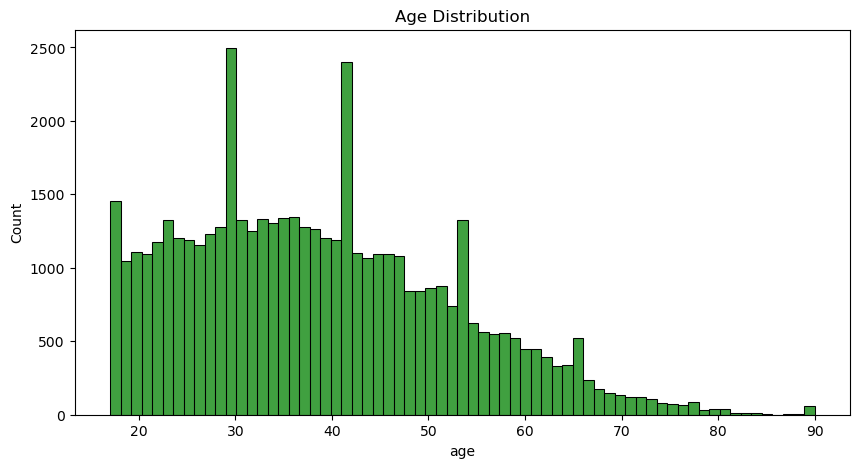

In [15]:
plt.figure(figsize=[10,5])
sns.histplot(data=df,x='age',color='green')
plt.title('Age Distribution')
plt.show()

In [16]:
print(f"Min age in the dataset = {df['age'].min()}")
print(f"Max age in the dataset = {df['age'].max()}")

Min age in the dataset = 17
Max age in the dataset = 90


In [17]:
df['education'].value_counts()

education
HS-grad         15770
Some-college    10862
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

In [18]:
print(f"Most common education level in the dataset is {df['education'].value_counts().idxmax()}")

Most common education level in the dataset is HS-grad


In [19]:
df['workclass'].value_counts()

workclass
Private             36654
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

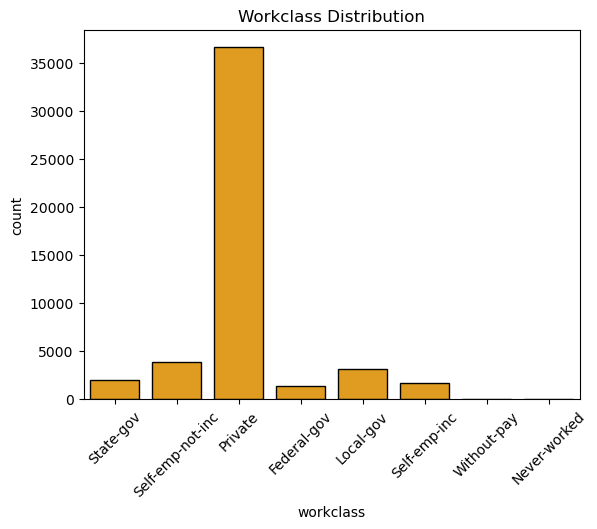

In [20]:
sns.countplot(data=df,x='workclass',color='orange',edgecolor='black')
plt.title('Workclass Distribution')
plt.xticks(rotation=45)
plt.show()

In [21]:
print(f"About {(df['workclass']=='Private').sum()*100/len(df):.2f}% peoples belongs to {df['workclass'].value_counts().idxmax()} class")

About 75.13% peoples belongs to Private class


In [22]:
edu_lvl_mapping=df.groupby('education')['education_num'].first().sort_values().reset_index()
print("EDUCATION LEVELS")
edu_lvl_mapping

EDUCATION LEVELS


,education,education_num
0,Preschool,1
1,1st-4th,2
2,5th-6th,3
3,7th-8th,4
4,9th,5
5,10th,6
6,11th,7
7,12th,8
8,HS-grad,9
9,Some-college,10


In [23]:
df['martial_status'].value_counts()

martial_status
Married-civ-spouse       22366
Never-married            16081
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

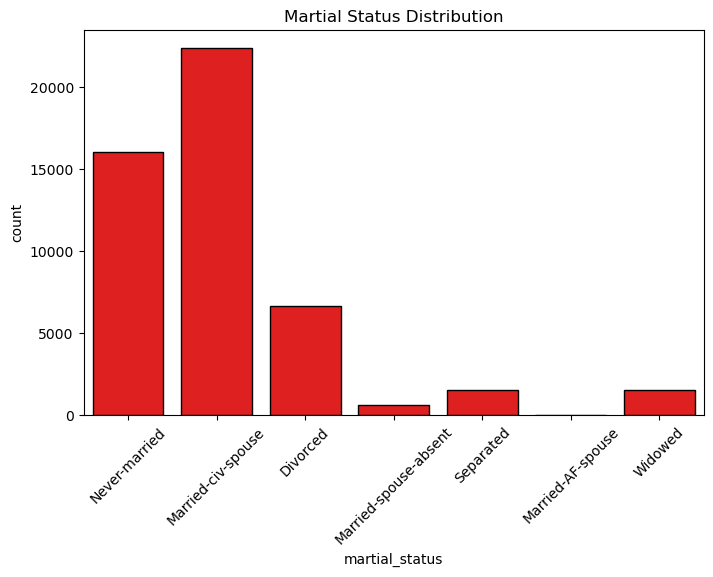

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='martial_status',color='red',edgecolor='black')
plt.title('Martial Status Distribution')
plt.xticks(rotation=45)
plt.show()

In [25]:
print(f'Most Common Martial Staus of peoples are {df['martial_status'].value_counts().idxmax()} of about {(df["martial_status"]=='Married-civ-spouse').sum()*100/len(df):.2f}%')

Most Common Martial Staus of peoples are Married-civ-spouse of about 45.84%


In [26]:
occ=df['occupation'].value_counts()
occ.reset_index()

,occupation,count
0,Prof-specialty,8969
1,Craft-repair,6102
2,Exec-managerial,6082
3,Adm-clerical,5606
4,Sales,5501
5,Other-service,4919
6,Machine-op-inspct,3017
7,Transport-moving,2355
8,Handlers-cleaners,2071
9,Farming-fishing,1485


In [27]:
print(f"Most common occupation in the dataset is {df['occupation'].value_counts().idxmax()} of about {(df['occupation']=='Prof-specialty').sum()*100/len(df):.2f}%")

Most common occupation in the dataset is Prof-specialty of about 18.38%


In [28]:
df['relationship'].value_counts()

relationship
Husband           19703
Not-in-family     12557
Own-child          7568
Unmarried          5124
Wife               2331
Other-relative     1506
Name: count, dtype: int64

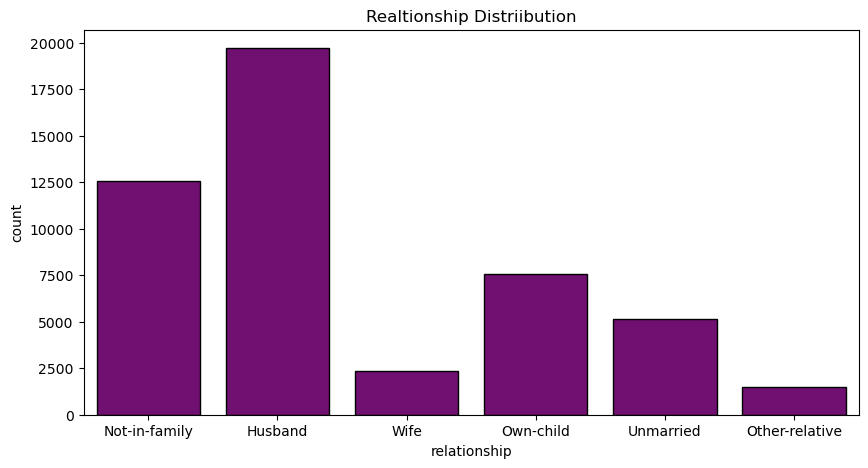

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='relationship',color='purple',edgecolor='black')
plt.title('Realtionship Distriibution')
plt.show()

In [30]:
print(f"About {(df['relationship']=='Husband').sum()*100/len(df):.2f}% Individuals in the dataset have the relationship status of Husband")

About 40.38% Individuals in the dataset have the relationship status of Husband


In [31]:
race_count=df['race'].value_counts()
race_count.reset_index()

,race,count
0,White,41713
1,Black,4683
2,Asian-Pac-Islander,1517
3,Amer-Indian-Eskimo,470
4,Other,406


In [32]:
print(f"Most Individuals Belongs to the {race_count.idxmax()} race of about {(df['race']=='White').sum()*100/len(df):.2f}%")

Most Individuals Belongs to the White race of about 85.50%


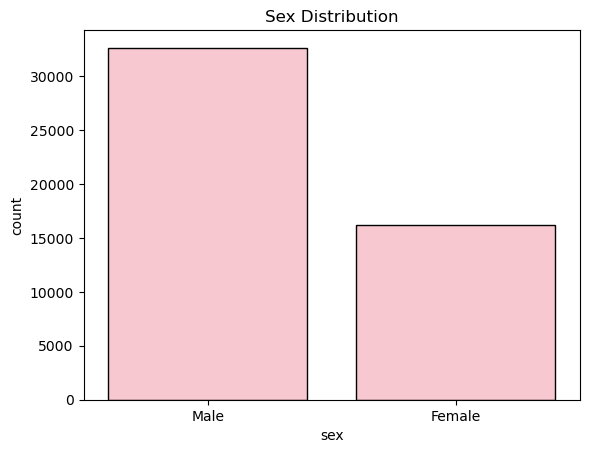

In [33]:
sns.countplot(data=df,x='sex',color='pink',edgecolor='black')
plt.title('Sex Distribution')
plt.show()

In [34]:
print(f"About {(df['sex']=='Male').sum()*100/len(df):.2f}% of individuals are Male")

About 66.85% of individuals are Male


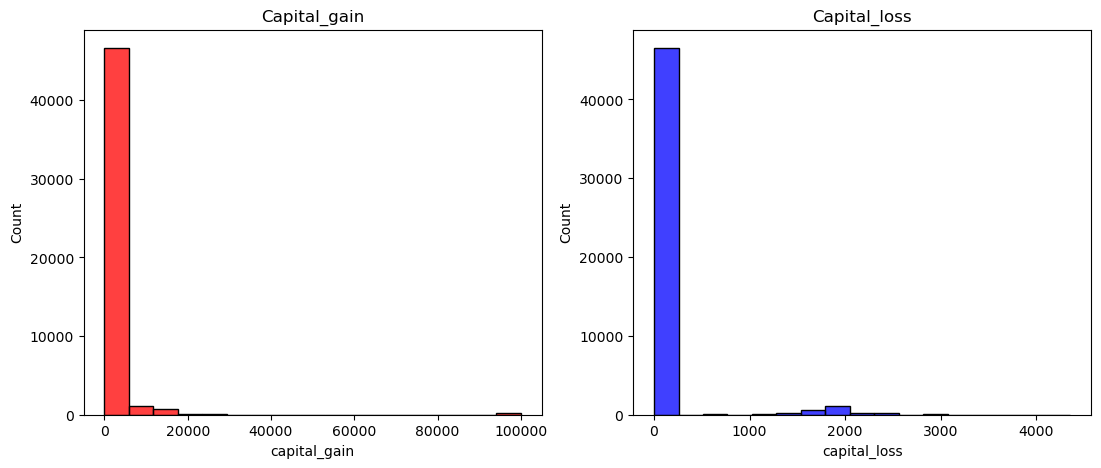

In [35]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
sns.histplot(data=df,x='capital_gain',ax=ax[0],color='red')
ax[0].set_title('Capital_gain')
sns.histplot(data=df,x='capital_loss',ax=ax[1],color='blue')
ax[1].set_title('Capital_loss')
plt.show()

In [36]:
print(f"About {((df['capital_gain']==0)&(df['capital_loss']==0)).sum()*100/len(df):.2f}% of peoples have neither capital gain nor capital loss")

About 87.05% of peoples have neither capital gain nor capital loss


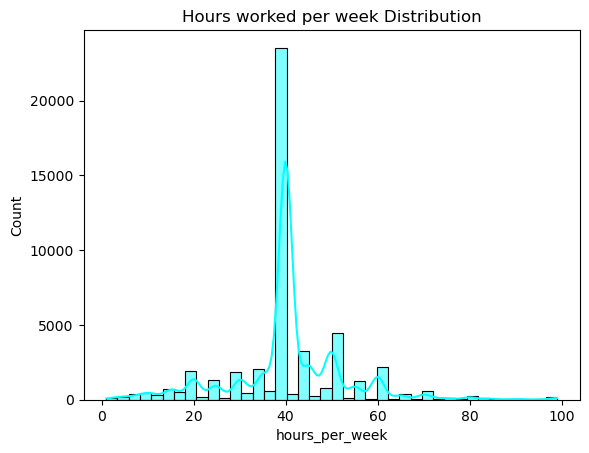

In [37]:
sns.histplot(data=df,x='hours_per_week',kde=True,bins=40,color='cyan')
plt.title('Hours worked per week Distribution')
plt.show()

In [38]:
print(f"Average Individual work about {df['hours_per_week'].mean():.1f} hours per week" )

Average Individual work about 40.4 hours per week


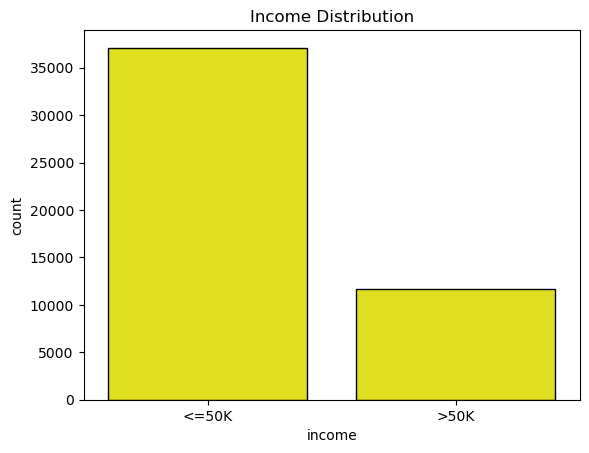

In [39]:
sns.countplot(x=df['income'],color='yellow',edgecolor='black')
plt.title('Income Distribution')
plt.show()

In [40]:
print(f"Most peoples have an annual income of 50K or less")

Most peoples have an annual income of 50K or less


# 7.BIVARITE ANALYSIS

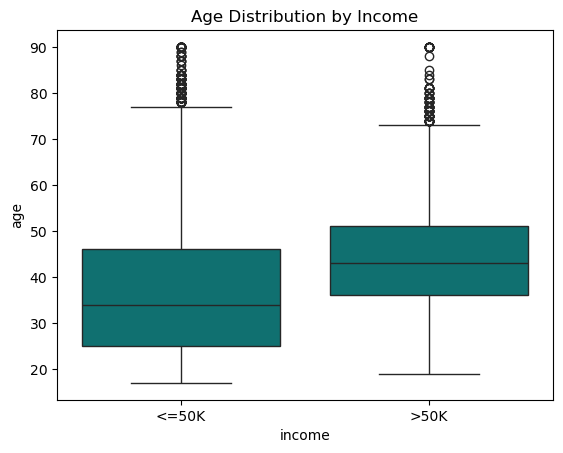

In [41]:
sns.boxplot(data=df,y='age',x='income',color='teal')
plt.title('Age Distribution by Income')
plt.show()

In [42]:
print(f"Average age of people income less than 50 k is {df.groupby('income')['age'].mean()['<=50K']:.2f} year")
print(f"Average age of people income above than 50 k is {df.groupby('income')['age'].mean()['>50K']:.2f} year")

Average age of people income less than 50 k is 36.88 year
Average age of people income above than 50 k is 44.28 year


In [43]:
income_wc=(pd.crosstab(df['workclass'],df['income'],normalize='index')*100).round(2)
income_wc

income,<=50K,>50K
workclass,,
Federal-gov,60.82,39.18
Local-gov,70.44,29.56
Never-worked,100.00,0.00
Private,79.14,20.86
Self-emp-inc,44.63,55.37
Self-emp-not-inc,72.11,27.89
State-gov,73.25,26.75
Without-pay,90.48,9.52


In [44]:
print(f"Individuals in the Self-emp-inc workclass have the highest percentage of annual incomes above $50K ({income_wc.loc['Self-emp-inc', '>50K']}%)")

Individuals in the Self-emp-inc workclass have the highest percentage of annual incomes above $50K (55.37%)


In [45]:
income_edu=(pd.crosstab(df['education'],df['income'],normalize='index')*100).round(2)
income_edu

income,<=50K,>50K
education,,
10th,93.74,6.26
11th,94.92,5.08
12th,92.67,7.33
1st-4th,96.73,3.27
5th-6th,94.67,5.33
7th-8th,93.50,6.50
9th,94.58,5.42
Assoc-acdm,74.20,25.80
Assoc-voc,74.66,25.34


In [46]:
print(f"Individual with education level of Prof-school has the highest percenatge of annual income above 50k ({income_edu.loc['Prof-school','>50K']}%)")

Individual with education level of Prof-school has the highest percenatge of annual income above 50k (73.98%)


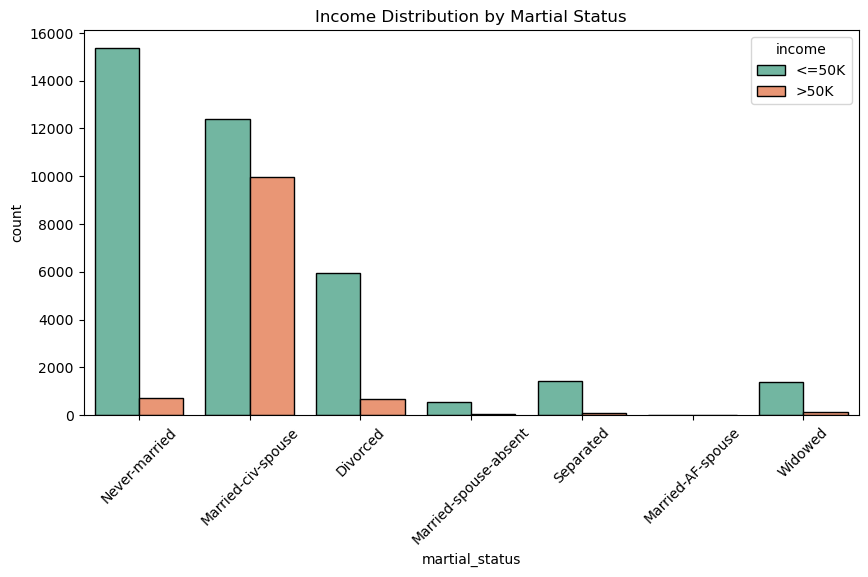

In [47]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='martial_status',hue='income',palette='Set2',edgecolor='black')
plt.title('Income Distribution by Martial Status')
plt.xticks(rotation=45)
plt.show()

In [48]:
income_martial=(pd.crosstab(df['martial_status'],df['income'],normalize='index')*100).round(2)
income_martial

income,<=50K,>50K
martial_status,,
Divorced,89.88,10.12
Married-AF-spouse,62.16,37.84
Married-civ-spouse,55.39,44.61
Married-spouse-absent,90.75,9.25
Never-married,95.44,4.56
Separated,93.53,6.47
Widowed,91.57,8.43


In [49]:
print(f"People with martial_status of Married-civ-spouse has the highest percentage of annual income above 50k ({income_martial.loc['Married-civ-spouse','>50K']}%)")

People with martial_status of Married-civ-spouse has the highest percentage of annual income above 50k (44.61%)


In [50]:
income_occ=(pd.crosstab(df['occupation'],df['income'],normalize='index')*100).round(2)
income_occ

income,<=50K,>50K
occupation,,
Adm-clerical,86.30,13.70
Armed-Forces,66.67,33.33
Craft-repair,77.35,22.65
Exec-managerial,52.22,47.78
Farming-fishing,88.35,11.65
Handlers-cleaners,93.34,6.66
Machine-op-inspct,87.70,12.30
Other-service,95.85,4.15
Priv-house-serv,98.75,1.25


In [51]:
print(f"Individual with occupation as Exec-managerial has the highest percentage of annual income above 50k ({income_occ.loc['Exec-managerial','>50K']}%)")

Individual with occupation as Exec-managerial has the highest percentage of annual income above 50k (47.78%)


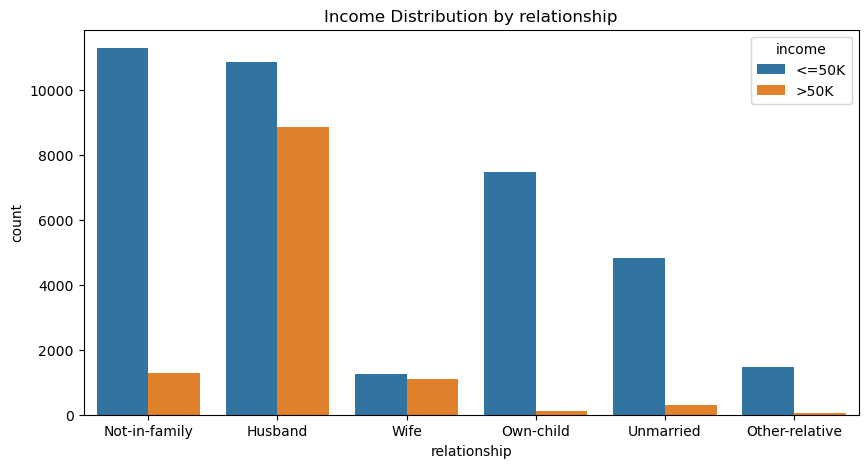

In [52]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='relationship',hue='income')
plt.title('Income Distribution by relationship')
plt.show()

In [53]:
income_rel=(pd.crosstab(df['relationship'],df['income'],normalize='index')*100).round(2)
income_rel

income,<=50K,>50K
relationship,,
Husband,55.13,44.87
Not-in-family,89.84,10.16
Other-relative,96.55,3.45
Own-child,98.53,1.47
Unmarried,93.97,6.03
Wife,53.11,46.89


In [54]:
print(f"Individuals relationship as Wife has the higher percentage of annual income above 50k ({income_rel.loc['Wife','>50K']}%)")

Individuals relationship as Wife has the higher percentage of annual income above 50k (46.89%)


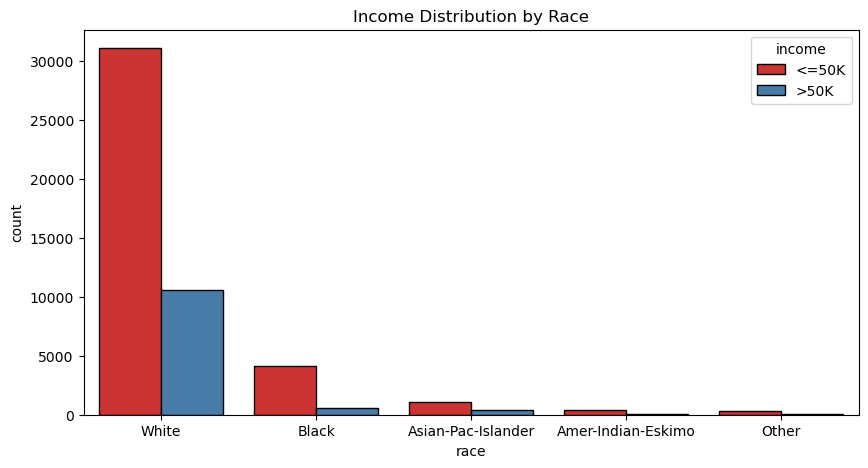

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='race',hue='income',palette='Set1',edgecolor='black')
plt.title('Income Distribution by Race')
plt.show()

In [56]:
income_race=(pd.crosstab(df['race'],df['income'],normalize='index')*100).round(2)
income_race

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,88.30,11.70
Asian-Pac-Islander,73.04,26.96
Black,87.91,12.09
Other,87.68,12.32
White,74.59,25.41


In [57]:
print(f"Individuals with Asain-Pac-Islander Race has the percentage of annual income above 50K ({income_race.loc['Asian-Pac-Islander','>50K']}%)")

Individuals with Asain-Pac-Islander Race has the percentage of annual income above 50K (26.96%)


<Axes: xlabel='sex', ylabel='count'>

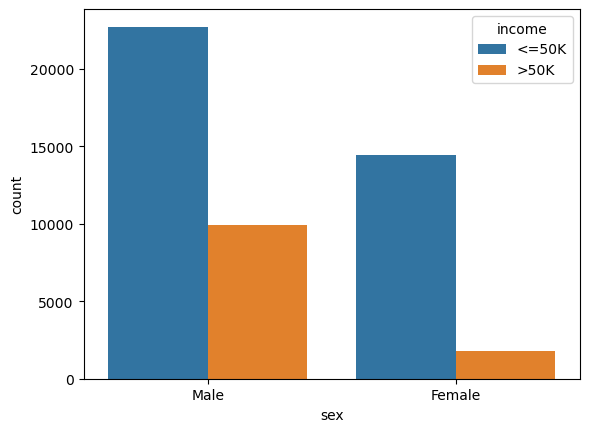

In [58]:
sns.countplot(data=df,x='sex',hue='income')

In [59]:
income_sex=(pd.crosstab(df['sex'],df['income'],normalize='index')*100).round(2)
income_sex

income,<=50K,>50K
sex,,
Female,89.06,10.94
Male,69.61,30.39


In [60]:
print(f"Male individuals have a higher percentage of annual incomes above $50K ({income_sex.loc['Male', '>50K']}%)")

Male individuals have a higher percentage of annual incomes above $50K (30.39%)


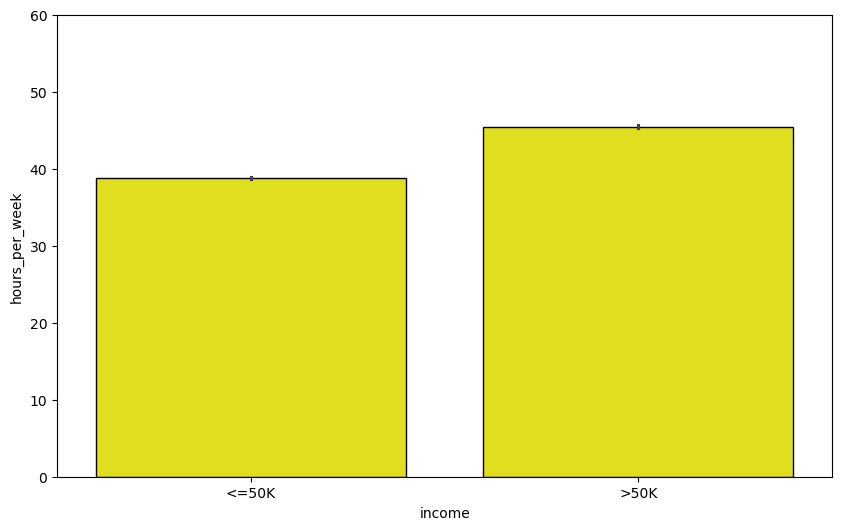

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,y='hours_per_week',x='income',color='yellow',edgecolor='black')
plt.yticks(np.linspace(0,60,7))
plt.show()

In [62]:
print(f"Individuals with annual income above $50K work an average of {df[df['income'] == '>50K']['hours_per_week'].mean():.2f} hours per week")

Individuals with annual income above $50K work an average of 45.45 hours per week


In [63]:
income_cntry=(pd.crosstab(df['native_country'],df['income'],normalize='index')*100).round(2)
income_cntry

income,<=50K,>50K
native_country,,
Cambodia,67.86,32.14
Canada,65.38,34.62
China,70.49,29.51
Columbia,95.29,4.71
Cuba,75.36,24.64
Dominican-Republic,95.15,4.85
Ecuador,86.67,13.33
El-Salvador,92.90,7.10
England,62.99,37.01


In [64]:
print(f"Individual with highest percentage of annual income above 50K has France as their native country ({income_cntry.loc['France','>50K']}%)")

Individual with highest percentage of annual income above 50K has France as their native country (42.11%)


# 8.KEY INSIGHTS

- The youngest individual in the dataset is **17 years**, while the oldest is **90 years**.
- Around **75.13%** of individuals belong to the **Private** workclass.
- The most common education level is **HS-grad**.
- **Married-civ-spouse** is the most common marital status, accounting for **45.84%** of individuals.
- The most common occupation is **Prof-specialty** (**18.38%**).
- Around **40.38%** of individuals have the relationship status of **Husband**.
- The majority of individuals belong to the **White** race (**85.50%**).
- **Male** individuals outnumber females in the dataset.
- About **87.05%** of individuals have **no capital gain or capital loss**.
- On average, individuals work **40.4 hours per week**.
- Most individuals earn an annual income of **$50K or less**.


In [65]:
df=df.drop(['education','fnlwgt'],axis=1)

In [66]:
onehot_en=['workclass','martial_status','occupation','relationship','sex','race','native_country']
df=pd.get_dummies(df,columns=onehot_en,drop_first=True,dtype=int)

In [67]:
df['income']=df['income'].map({'>50K':1,'<=50K':0})

In [68]:
df[['capital_gain','capital_loss']]=np.log1p(df[['capital_gain','capital_loss']])

In [69]:
X=df.drop('income',axis=1)
y=df['income']

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler=StandardScaler()

In [74]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
model1=LogisticRegression(random_state=42,class_weight='balanced',solver='liblinear',C=0.1)

In [77]:
model1.fit(X_train,y_train)

LogisticRegression(C=0.1, class_weight='balanced', random_state=42,
                   solver='liblinear')

In [106]:
train=model1.score(X_train,y_train)
test=model1.score(X_test,y_test)
print(train)
print(test)

0.801762114537445
0.7998882057015092


In [78]:
y_prob=model1.predict_proba(X_test)[:,1]
y_pred1=(y_prob>=0.75).astype(int)

In [79]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [80]:
acc1=accuracy_score(y_test,y_pred1)

In [81]:
acc1

0.8405689087634308

In [82]:
confusion_matrix(y_test,y_pred1,labels=[1,0])

array([[ 2384,  1574],
       [  993, 11150]])

In [83]:
print("Recall Score =",recall_score(y_test,y_pred1))
print("Precision Score =",precision_score(y_test,y_pred1))
print("F1 Score =",f1_score(y_test,y_pred1))

Recall Score = 0.6023244062657908
Precision Score = 0.7059520284275984
F1 Score = 0.6500340831629176


In [85]:
from sklearn.tree import DecisionTreeClassifier

In [177]:
model2=DecisionTreeClassifier(random_state=42,class_weight='balanced',max_depth=9,min_samples_split=20,min_samples_leaf=4,criterion='entropy')

In [178]:
model2.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=9, min_samples_leaf=4, min_samples_split=20,
                       random_state=42)

In [179]:
train=model2.score(X_train,y_train)
test=model2.score(X_test,y_test)
print(train)
print(test)

0.8178230543318649
0.8080243463138935


In [180]:
y_pred2=model2.predict(X_test)

In [181]:
acc2=accuracy_score(y_test,y_pred2)
acc2

0.8080243463138935

In [182]:
print("Recall Score =",recall_score(y_test,y_pred2))
print("Precision Score =",precision_score(y_test,y_pred2))
print("F1 Score =",f1_score(y_test,y_pred2))

Recall Score = 0.8383021728145528
Precision Score = 0.5751430057202288
F1 Score = 0.6822247352729516


In [183]:
import joblib 

In [185]:
joblib.dump(model2,'annual_income.pkl')

['annual_income.pkl']

In [186]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [197]:
X.columns

Index(['age', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'workclass_Local-gov', 'workclass_Never-worked',
       'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'martial_status_Married-AF-spouse',
       'martial_status_Married-civ-spouse',
       'martial_status_Married-spouse-absent', 'martial_status_Never-married',
       'martial_status_Separated', 'martial_status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'relationship_Not-in-family',
       'relationship_Other-relative', 'relati